> **Essential ML process for Intrusion Detection**
<br>` python  3.7.13    scikit-learn  1.0.2 `
<br>`numpy   1.19.5          pandas  1.3.5`

**Import the main libraries**

In [11]:
import numpy
import pandas

from time import time

import os
data_path = '../data'  # Updated for Assignment folder structure

_import the local library_

In [12]:
# add parent folder path where lib folder is
import sys
if ".." not in sys.path:import sys; sys.path.insert(0, '..') 

In [13]:
from mylib import show_labels_dist, show_metrics, bias_var_metrics

**Import the Dataset**

In [14]:
# Using boosted Train and preprocessed Test

data_file = os.path.join(data_path, 'NSL_boosted-2.csv') 
train_df = pandas.read_csv(data_file)
print('Train Dataset: {} rows, {} columns'.format(train_df.shape[0], train_df.shape[1]))

data_file = os.path.join(data_path, 'NSL_ppTest.csv') 
test_df = pandas.read_csv(data_file)
print('Test Dataset: {} rows, {} columns'.format(test_df.shape[0], test_df.shape[1]))

Train Dataset: 63280 rows, 43 columns
Test Dataset: 22544 rows, 43 columns


***
**Data Preparation and EDA** (unique to this dataset)

* _Check column names of numeric attributes_

In [15]:
trnn = train_df.select_dtypes(include=['float64','int64']).columns
tstn = test_df.select_dtypes(include=['float64','int64']).columns
trndif = numpy.setdiff1d(trnn, tstn)
tstdif = numpy.setdiff1d(tstn, trnn)

print("Numeric features in the train_set that are not in the test_set: ",end='')
if len(trndif) > 0:
    print('\n',trndif)
else:
    print('None')

print("Numeric features in the test_set that are not in the train_set: ",end='')
if len(tstdif) > 0:
    print('\n',tstdif)
else:
    print('None')

print()
# correct any differences here

Numeric features in the train_set that are not in the test_set: None
Numeric features in the test_set that are not in the train_set: None



* _Check column names of categorical attributes_

In [16]:
trnn = train_df.select_dtypes(include=['object']).columns
tstn = test_df.select_dtypes(include=['object']).columns
trndif = numpy.setdiff1d(trnn, tstn)
tstdif = numpy.setdiff1d(tstn, trnn)

print("Categorical features in the train_set that are not in the test_set: ",end='')
if len(trndif) > 0:
    print('\n',trndif)
else:
    print('None')

print("Categorical features in the test_set that are not in the train_set: ",end='')
if len(tstdif) > 0:
    print('\n\t',tstdif)
else:
    print('None')

print()
# correct any differences here

Categorical features in the train_set that are not in the test_set: None
Categorical features in the test_set that are not in the train_set: None



* _Check for missing values_

In [17]:
cnt=0
print('Missing Values - Train Set')
for col in train_df.columns:
#    print(col, ' ::> ', len(combined_df[col].unique()))
    nnul = pandas.notnull(train_df[col]) 
    if (len(nnul)!=len(train_df)):
        cnt=cnt+1
        print('\t',col,':',(len(test_df)-len(nnul)),'null values')
print('Total',cnt,'features with null values')

cnt=0
print('Missing Values - Test Set')
for col in test_df.columns:
#    print(col, ' ::> ', len(combined_df[col].unique()))
    nnul = pandas.notnull(test_df[col]) 
    if (len(nnul)!=len(test_df)):
        cnt=cnt+1
        print('\t',col,':',(len(test_df)-len(nnul)),'null values')
print('Total',cnt,'features with null values')

# address missing values here

Missing Values - Train Set
Total 0 features with null values
Missing Values - Test Set
Total 0 features with null values


* _Quick visual check of unique values, deal with unique identifiers_

In [18]:
# Identify columns with only one value 
# or with number of unique values == number of rows
n_eq_one = []
n_eq_all = []

print('Unique value count: Train (',train_df.shape[0],'rows ) ~ Test(',test_df.shape[0],'rows )')
for col in train_df.columns:
    lctrn = len(train_df[col].unique())
    lctst = len(test_df[col].unique())
    print(col, ' ::> ', lctrn, ' ~ ', lctst)
    if (lctrn == 1) and (lctrn == lctst): 
        n_eq_one.append(train_df[col].name)
    if lctrn == train_df.shape[0]:
        n_eq_all.append(train_df[col].name)

Unique value count: Train ( 63280 rows ) ~ Test( 22544 rows )
duration  ::>  1657  ~  624
protocol_type  ::>  3  ~  3
service  ::>  70  ~  64
flag  ::>  11  ~  11
src_bytes  ::>  2553  ~  1149
dst_bytes  ::>  6633  ~  3650
land  ::>  2  ~  2
wrong_fragment  ::>  3  ~  3
urgent  ::>  3  ~  4
hot  ::>  24  ~  16
num_failed_logins  ::>  6  ~  5
logged_in  ::>  2  ~  2
num_compromised  ::>  49  ~  23
root_shell  ::>  2  ~  2
su_attempted  ::>  3  ~  3
num_root  ::>  44  ~  20
num_file_creations  ::>  28  ~  9
num_shells  ::>  3  ~  4
num_access_files  ::>  9  ~  5
num_outbound_cmds  ::>  1  ~  1
is_host_login  ::>  2  ~  2
is_guest_login  ::>  2  ~  2
count  ::>  511  ~  495
srv_count  ::>  489  ~  457
serror_rate  ::>  87  ~  88
srv_serror_rate  ::>  75  ~  82
rerror_rate  ::>  81  ~  90
srv_rerror_rate  ::>  63  ~  93
same_srv_rate  ::>  101  ~  75
diff_srv_rate  ::>  88  ~  99
srv_diff_host_rate  ::>  61  ~  84
dst_host_count  ::>  256  ~  256
dst_host_srv_count  ::>  256  ~  256
dst_ho

In [19]:
# Drop columns with only one value
if len(n_eq_one) > 0:
    print('Dropping single-valued features')
    print(n_eq_one)
    train_df.drop(n_eq_one, axis=1, inplace=True)
    test_df.drop(n_eq_one, axis=1, inplace=True)

# Drop or bin columns with number of unique values == number of rows
if len(n_eq_all) > 0:
    print('Dropping unique identifiers')
    print(n_eq_all)
    train_df.drop(n_eq_all, axis=1, inplace=True)
    test_df.drop(n_eq_all, axis=1, inplace=True)

# continue with featue selection / feature engineering

Dropping single-valued features
['num_outbound_cmds']


* _Check categorical feature values:<br>
differences will be resolved by one-hot encoding the combined test and train sets_

In [20]:
trnn = train_df.select_dtypes(include=['object']).columns
for col in trnn:
    tr = train_df[col].unique()
    ts = test_df[col].unique()
    trd = numpy.setdiff1d(tr, ts)
    tsd = numpy.setdiff1d(ts, tr)
    
    print(col,'::> ')
    print("\tUnique text values in the train_set that are not in the test_set: ",end='')
    if len(trd) > 0:
        print('\n\t',trd)
    else:
        print('None')
    
    print("\tUnique text values in the test_set that are not in the train_set: ",end='')
    if len(tsd) > 0:
        print('\n\t',tsd)
    else:
        print('None')

protocol_type ::> 
	Unique text values in the train_set that are not in the test_set: None
	Unique text values in the test_set that are not in the train_set: None
service ::> 
	Unique text values in the train_set that are not in the test_set: 
	 ['aol' 'harvest' 'http_2784' 'http_8001' 'red_i' 'urh_i']
	Unique text values in the test_set that are not in the train_set: None
flag ::> 
	Unique text values in the train_set that are not in the test_set: None
	Unique text values in the test_set that are not in the train_set: None
label ::> 
	Unique text values in the train_set that are not in the test_set: 
	 ['spy' 'warezclient']
	Unique text values in the test_set that are not in the train_set: None
atakcat ::> 
	Unique text values in the train_set that are not in the test_set: None
	Unique text values in the test_set that are not in the train_set: None


* _Combine for processing classification target and text features_

In [21]:
combined_df = pandas.concat([train_df, test_df])
print('Combined Dataset: {} rows, {} columns'.format(
    combined_df.shape[0], combined_df.shape[1]))

Combined Dataset: 85824 rows, 42 columns


* _Classification Target feature:_
two columns of labels are available 
    * Two-class: Reduce the detailed attack labels to 'normal' or 'attack'
    * Multiclass: Use the category labels (atakcat)

In [22]:
combined_df['label'].value_counts()

label
normal             43383
neptune            25264
satan               2552
smurf               1988
ipsweep             1941
portsweep           1623
guess_passwd        1257
mscan               1046
warezmaster          954
back                 837
nmap                 820
apache2              774
processtable         719
teardrop             458
warezclient          445
snmpguess            364
saint                350
mailbomb             322
snmpgetattack        196
httptunnel           146
pod                  142
buffer_overflow       35
named                 25
ps                    22
multihop              21
sendmail              21
xterm                 20
rootkit               18
land                  16
xlock                 14
xsnoop                 8
ftp_write              7
imap                   6
loadmodule             6
phf                    6
perl                   5
worm                   4
sqlattack              4
udpstorm               4
spy                

In [23]:
combined_df['atakcat'].value_counts()

atakcat
benign    43383
dos       30524
probe      8332
r2l        3329
u2r         256
Name: count, dtype: int64

In [24]:
# Set the classification target
twoclass = True     # True or False

In [25]:
if twoclass:
# Two-class: Reduce the detailed attack labels to 'normal' or 'attack'
# new single column data structure is a [series]
    labels_df = combined_df['label'].copy()
    labels_df[labels_df != 'normal'] = 'attack'
else:
# Multiclass: Use the category labels (atakcat)
# new single column data structure is a [[dataframe]]
# rename the column and convert to a series for later
    labels_df = combined_df[['atakcat']].copy()
    labels_df.rename(columns={'atakcat':'label'}, inplace=True)
    labels_df = labels_df.squeeze('columns')

# drop target features 
combined_df.drop(['label'], axis=1, inplace=True)
combined_df.drop(['atakcat'], axis=1, inplace=True)

* _One-Hot Encoding the categorical (text) features_

In [26]:
# put the names into a python list - for pandas.get_dummies()
categori = combined_df.select_dtypes(include=['object']).columns
category_cols = categori.tolist()
print(category_cols)

['protocol_type', 'service', 'flag']


In [27]:
# generate a sorted list of unique values of categorical features
# we will get a new column for each one with get_dummies()

for col in categori:
    ul = numpy.sort(list(combined_df[col].unique()))
    print(col, ' ::> ', ul)
    print()

protocol_type  ::>  ['icmp' 'tcp' 'udp']

service  ::>  ['IRC' 'X11' 'Z39_50' 'aol' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf'
 'daytime' 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs'
 'exec' 'finger' 'ftp' 'ftp_data' 'gopher' 'harvest' 'hostnames' 'http'
 'http_2784' 'http_443' 'http_8001' 'imap4' 'iso_tsap' 'klogin' 'kshell'
 'ldap' 'link' 'login' 'mtp' 'name' 'netbios_dgm' 'netbios_ns'
 'netbios_ssn' 'netstat' 'nnsp' 'nntp' 'ntp_u' 'other' 'pm_dump' 'pop_2'
 'pop_3' 'printer' 'private' 'red_i' 'remote_job' 'rje' 'shell' 'smtp'
 'sql_net' 'ssh' 'sunrpc' 'supdup' 'systat' 'telnet' 'tftp_u' 'tim_i'
 'time' 'urh_i' 'urp_i' 'uucp' 'uucp_path' 'vmnet' 'whois']

flag  ::>  ['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']



In [28]:
# Apply to the list of Categorical columns (text fields)
features_df = pandas.get_dummies(combined_df, columns=category_cols)
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85824 entries, 0 to 22543
Columns: 121 entries, duration to flag_SH
dtypes: bool(84), float64(15), int64(22)
memory usage: 31.8 MB


In [29]:
# generate a list of numeric columns for scaling - After test // train split
numeri = combined_df.select_dtypes(include=['float64','int64']).columns
print(numeri.to_list())

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


***
**<br>Create Test // Train Datasets**
> Normally we split the dataset into train 70 % // test 30 % like this
<br>`from sklearn.model_selection import train_test_split`
<br>`X_train, X_test, y_train, y_test = `
<br>`    train_test_split(features_df, labels_df, `
<br>`        test_size=0.3, stratify=labels_df, random_state=42)`

In [30]:
# Restore the train // test split: slice 1 Dataframe into 2 
features_train = features_df.iloc[:len(train_df),:].copy()    # X_train
features_train.reset_index(inplace=True, drop=True)
# pandas has a lot of rules about returning a 'view' vs. a copy from slice
# so we force it to create a new dataframe [avoiding SettingWithCopy Warning]
features_test = features_df.iloc[len(train_df):,:].copy()     # X_test
features_test.reset_index(inplace=True, drop=True)

# Restore the train // test split: slice 1 Series into 2 
labels_train = labels_df[:len(train_df)]               # y_train
labels_train.reset_index(inplace=True, drop=True)

labels_test = labels_df[len(train_df):]                # y_test
labels_test.reset_index(inplace=True, drop=True)

***
Next are standard steps for all datasets: _scaling, classifiers, results_

**Scaling** comes _after_ test // train split

In [31]:
# scaling the Numeric columns 
# StandardScaler range: -1 to 1, MinMaxScaler range: zero to 1

# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# sklearn docs say 
#   "Don't cheat - fit only on training data, then transform both"
#   fit() expects 2D array: reshape(-1, 1) for single col or (1, -1) single row

for i in numeri:
    arr = numpy.array(features_train[i])
    scale = MinMaxScaler().fit(arr.reshape(-1, 1))
    features_train[i] = scale.transform(arr.reshape(len(arr),1))

    arr = numpy.array(features_test[i])
    features_test[i] = scale.transform(arr.reshape(len(arr),1))

**<br>Classifier Selection**

In [32]:
# prepare list
models = []

##  --  Linear  --  ## 
#from sklearn.linear_model import LogisticRegression 
#models.append (("LogReg",LogisticRegression())) 
#from sklearn.linear_model import SGDClassifier 
#models.append (("StocGradDes",SGDClassifier())) 
#from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
#models.append(("LinearDA", LinearDiscriminantAnalysis())) 

##  --  Support Vector  --  ## 
#from sklearn.svm import SVC 
#models.append(("SupportVectorClf", SVC())) 

##  --  Non-linear  --  ## 
#from sklearn.tree import DecisionTreeClassifier 
#models.append (("DecisionTree",DecisionTreeClassifier())) 
#from sklearn.neighbors import KNeighborsClassifier 
#models.append(("K-NNeighbors", KNeighborsClassifier())) 

##  --  Ensemble: bagging  --  ## 
from sklearn.ensemble import RandomForestClassifier 
models.append(("RandomForest", RandomForestClassifier())) 
from sklearn.ensemble import BaggingClassifier
models.append(("BaggingClf", BaggingClassifier()))
from sklearn.ensemble import ExtraTreesClassifier
models.append(("ExtraTrees", ExtraTreesClassifier()))

##  --  Ensemble: boosting  --  ## 
#from sklearn.ensemble import AdaBoostClassifier 
#models.append(("AdaBoost", AdaBoostClassifier())) 
#from sklearn.ensemble import GradientBoostingClassifier 
#models.append(("GradientBoost", GradientBoostingClassifier())) 

print(models)

[('RandomForest', RandomForestClassifier()), ('BaggingClf', BaggingClassifier()), ('ExtraTrees', ExtraTreesClassifier())]


<br>_compatibility block for pasting in from sample code_

In [33]:
# dataset names
X_train = features_train
y_train = labels_train
X_test = features_test
y_test = labels_test
labels_col = 'label'
# library names
pd = pandas
np = numpy

**<br>Target Label Distributions** (standard block)

In [34]:
# from our local library
show_labels_dist(X_train,X_test,y_train,y_test)

features_train: 63280 rows, 121 columns
features_test:  22544 rows, 121 columns

labels_train: 63280 rows, 1 column
labels_test:  22544 rows, 1 column

Frequency and Distribution of labels
        label  %_train  label  %_test
label                                
normal  33672    53.21   9711   43.08
attack  29608    46.79  12833   56.92


_... this is a good place for the ClassBalance visualizer ..._

**<br>Fit and Predict** (standard block)

In [35]:
# evaluate each model in turn
results = []

print('macro average: unweighted mean per label')
print('weighted average: support-weighted mean per label')
print('MCC: correlation between prediction and ground truth')
print('     (+1 perfect, 0 random prediction, -1 inverse)\n')

for name, clf in models:
    trs = time()
    print('Confusion Matrix:', name)
    
    clf.fit(X_train, y_train)
    ygx = clf.predict(X_test)
    results.append((name, ygx))
    
    tre = time() - trs
    print ("Run Time {} seconds".format(round(tre,2)) + '\n')
    
# Easy way to ensure that the confusion matrix rows and columns
#   are labeled exactly as the classifier has coded the classes
#   [[note the _ at the end of clf.classes_ ]]

    show_metrics(y_test, ygx, clf.classes_)   # from our local library
    print('\nParameters: ', clf.get_params(), '\n\n')

macro average: unweighted mean per label
weighted average: support-weighted mean per label
MCC: correlation between prediction and ground truth
     (+1 perfect, 0 random prediction, -1 inverse)

Confusion Matrix: RandomForest
Run Time 6.58 seconds

              pred:attack  pred:normal
train:attack        10527         2306
train:normal          431         9280

~~~~
   macro avg :  FPR = 0.112   FNR = 0.112
weighted avg :  FPR = 0.121   FNR = 0.121

~~~~
              precision    recall  f1-score   support

      attack      0.961     0.820     0.885     12833
      normal      0.801     0.956     0.871      9711

    accuracy                          0.879     22544
   macro avg      0.881     0.888     0.878     22544
weighted avg      0.892     0.879     0.879     22544

~~~~
MCC: Overall :  0.769

Parameters:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 

**Bias - Variance Decomposition** (standard block)

In [37]:
# from our local library
# reduce (cross-validation) folds for faster results
folds = 20
for name, clf in models:
    print('Bias // Variance Decomposition:', name)
    bias_var_metrics(X_train,X_test,y_train,y_test,clf,folds)

Bias // Variance Decomposition: RandomForest
   Average bias: 0.119
   Average variance: 0.009
   Average expected loss: 0.122  "Goodness": 0.878

Bias // Variance Decomposition: BaggingClf
   Average bias: 0.110
   Average variance: 0.031
   Average expected loss: 0.108  "Goodness": 0.892

Bias // Variance Decomposition: ExtraTrees
   Average bias: 0.140
   Average variance: 0.012
   Average expected loss: 0.138  "Goodness": 0.862



***

***

**<br>Baseline Model**
>Select this block - Go to the Run menu - Run all Above
<br> Then paste in blocks below from the other examples  
and run them one at a time

***

***
**Hyperparameter Tuning**
General pattern:<br>
_baseline model_<br>
>    1. Classifier selection<br> 
   2. Fit and Predict<br>
   3. Bias-Variance Tradeoff<br>
    
_optimised model_<br>
>    4. Select strategy and hyperparameters<br>
   5. Plug in the best parameter values<br>
   6. Fit and Predict<br>
   7. Bias-Variance Tradeoff

 ***

In [39]:
# ============================================================
# HYPERPARAMETER TUNING - ENSEMBLE BAGGING CLASSIFIERS
# ============================================================
# KEY IMPROVEMENTS:
#   1. class_weight='balanced' via base estimator (handles class imbalance)
#   2. Multiple tuning configurations tested
#   3. Bias-variance analysis for tuned model
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

print("="*70)
print("HYPERPARAMETER TUNING - ENSEMBLE CLASSIFIERS")
print("="*70)
print("\nClass Distribution (Note: Test set differs from Train!):")
print(f"  Train: {(y_train=='normal').mean()*100:.1f}% normal, {(y_train=='attack').mean()*100:.1f}% attack")
print(f"  Test:  {(y_test=='normal').mean()*100:.1f}% normal, {(y_test=='attack').mean()*100:.1f}% attack")

HYPERPARAMETER TUNING - ENSEMBLE CLASSIFIERS

Class Distribution (Note: Test set differs from Train!):
  Train: 53.2% normal, 46.8% attack
  Test:  43.1% normal, 56.9% attack


In [40]:
# ============================================================
# STEP 1: BASELINE COMPARISON - All Ensemble Classifiers
# ============================================================

print("\n" + "="*70)
print("STEP 1: BASELINE COMPARISON")
print("="*70)

baseline_models = [
    ("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ("BaggingClassifier", BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ("ExtraTrees", ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1))
]

all_results = {}
for name, clf in baseline_models:
    print(f"\nTraining {name}...")
    trs = time()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    tre = time() - trs
    
    all_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'time': tre,
        'predictions': y_pred
    }
    print(f"  Bal_Acc: {all_results[name]['balanced_accuracy']:.4f} | F1: {all_results[name]['f1_score']:.4f} | Time: {tre:.2f}s")

# Identify best baseline
best_baseline = max(all_results.keys(), key=lambda x: all_results[x]['balanced_accuracy'])
baseline_ba = all_results[best_baseline]['balanced_accuracy']
print(f"\n>>> BEST BASELINE: {best_baseline} (Bal_Acc: {baseline_ba:.4f})")


STEP 1: BASELINE COMPARISON

Training RandomForest...
  Bal_Acc: 0.8927 | F1: 0.8834 | Time: 2.17s

Training BaggingClassifier...
  Bal_Acc: 0.9037 | F1: 0.8965 | Time: 20.75s

Training ExtraTrees...
  Bal_Acc: 0.8669 | F1: 0.8611 | Time: 2.44s

>>> BEST BASELINE: BaggingClassifier (Bal_Acc: 0.9037)


In [41]:
# ============================================================
# STEP 2: HYPERPARAMETER TUNING - BaggingClassifier
# ============================================================
# Tuning Strategy:
#   1. Increase n_estimators (100 -> 200)
#   2. Tune max_samples (fraction of training data)
#   3. Use class_weight='balanced' in base estimator (handles imbalance)
# ============================================================

print("\n" + "="*70)
print("STEP 2: HYPERPARAMETER TUNING")
print("="*70)

# Base estimator with class_weight to handle imbalanced data
dt_balanced = DecisionTreeClassifier(class_weight='balanced', random_state=42)

tuned_configs = [
    # Standard tuning - more estimators
    ("Bagging_200est", BaggingClassifier(n_estimators=200, max_samples=0.9, random_state=42, n_jobs=-1)),
    ("Bagging_150est", BaggingClassifier(n_estimators=150, max_samples=0.85, random_state=42, n_jobs=-1)),
    # With class_weight='balanced' base estimator (KEY IMPROVEMENT!)
    ("Bagging_200_balanced", BaggingClassifier(estimator=dt_balanced, n_estimators=200, max_samples=0.9, random_state=42, n_jobs=-1)),
    ("Bagging_150_balanced", BaggingClassifier(estimator=dt_balanced, n_estimators=150, max_samples=0.8, random_state=42, n_jobs=-1)),
]

for name, clf in tuned_configs:
    print(f"\nTraining {name}...")
    trs = time()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    tre = time() - trs
    
    all_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'time': tre,
        'predictions': y_pred
    }
    improvement = ((all_results[name]['balanced_accuracy'] - baseline_ba) / baseline_ba) * 100
    print(f"  Bal_Acc: {all_results[name]['balanced_accuracy']:.4f} | Improvement: {improvement:+.2f}%")

# Find best tuned model
tuned_names = [name for name, _ in tuned_configs]
best_tuned = max(tuned_names, key=lambda x: all_results[x]['balanced_accuracy'])
best_tuned_ba = all_results[best_tuned]['balanced_accuracy']
print(f"\n>>> BEST TUNED: {best_tuned} (Bal_Acc: {best_tuned_ba:.4f})")


STEP 2: HYPERPARAMETER TUNING

Training Bagging_200est...
  Bal_Acc: 0.9126 | Improvement: +0.98%

Training Bagging_150est...
  Bal_Acc: 0.9160 | Improvement: +1.36%

Training Bagging_200_balanced...
  Bal_Acc: 0.9074 | Improvement: +0.41%

Training Bagging_150_balanced...
  Bal_Acc: 0.9053 | Improvement: +0.17%

>>> BEST TUNED: Bagging_150est (Bal_Acc: 0.9160)


In [42]:
# ============================================================
# STEP 3: RESULTS COMPARISON TABLE
# ============================================================

print("\n" + "="*70)
print("STEP 3: ALL RESULTS COMPARISON")
print("="*70)

# Create results DataFrame
results_df = pandas.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Balanced_Acc': r['balanced_accuracy'],
        'F1_Score': r['f1_score'],
        'MCC': r['mcc'],
        'Time(s)': r['time']
    } for name, r in all_results.items()
}).T

# Sort by balanced accuracy
results_df = results_df.sort_values('Balanced_Acc', ascending=False)
print("\n" + results_df.to_string())

# Calculate improvement
overall_improvement = ((best_tuned_ba - baseline_ba) / baseline_ba) * 100
print(f"\n>>> IMPROVEMENT: {baseline_ba:.4f} -> {best_tuned_ba:.4f} ({overall_improvement:+.2f}%)")


STEP 3: ALL RESULTS COMPARISON

                      Accuracy  Balanced_Acc  F1_Score       MCC    Time(s)
Bagging_150est        0.909954      0.916047  0.910372  0.824382  25.321255
Bagging_200est        0.906050      0.912581  0.906494  0.817374  32.989377
Bagging_200_balanced  0.900106      0.907410  0.900587  0.806991  33.647630
Bagging_150_balanced  0.897667      0.905267  0.898160  0.802727  24.407847
BaggingClassifier     0.896026      0.903725  0.896526  0.799670  20.748790
RandomForest          0.882896      0.892656  0.883428  0.778149   2.174087
ExtraTrees            0.860406      0.866902  0.861077  0.726756   2.443440

>>> IMPROVEMENT: 0.9037 -> 0.9160 (+1.36%)


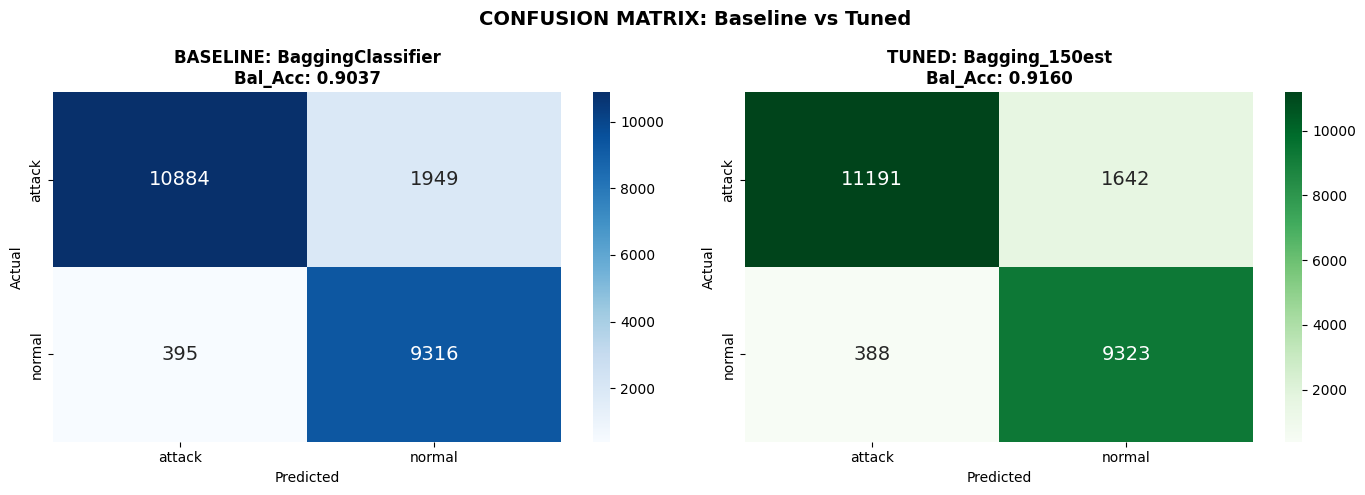

In [43]:
# ============================================================
# VISUALIZATION 1: Confusion Matrix Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline BaggingClassifier confusion matrix
cm_baseline = confusion_matrix(y_test, all_results['BaggingClassifier']['predictions'])
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['attack', 'normal'], yticklabels=['attack', 'normal'],
            annot_kws={'size': 14})
axes[0].set_title(f'BASELINE: BaggingClassifier\nBal_Acc: {all_results["BaggingClassifier"]["balanced_accuracy"]:.4f}', 
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Best Tuned confusion matrix
cm_tuned = confusion_matrix(y_test, all_results[best_tuned]['predictions'])
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['attack', 'normal'], yticklabels=['attack', 'normal'],
            annot_kws={'size': 14})
axes[1].set_title(f'TUNED: {best_tuned}\nBal_Acc: {best_tuned_ba:.4f}', 
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('CONFUSION MATRIX: Baseline vs Tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

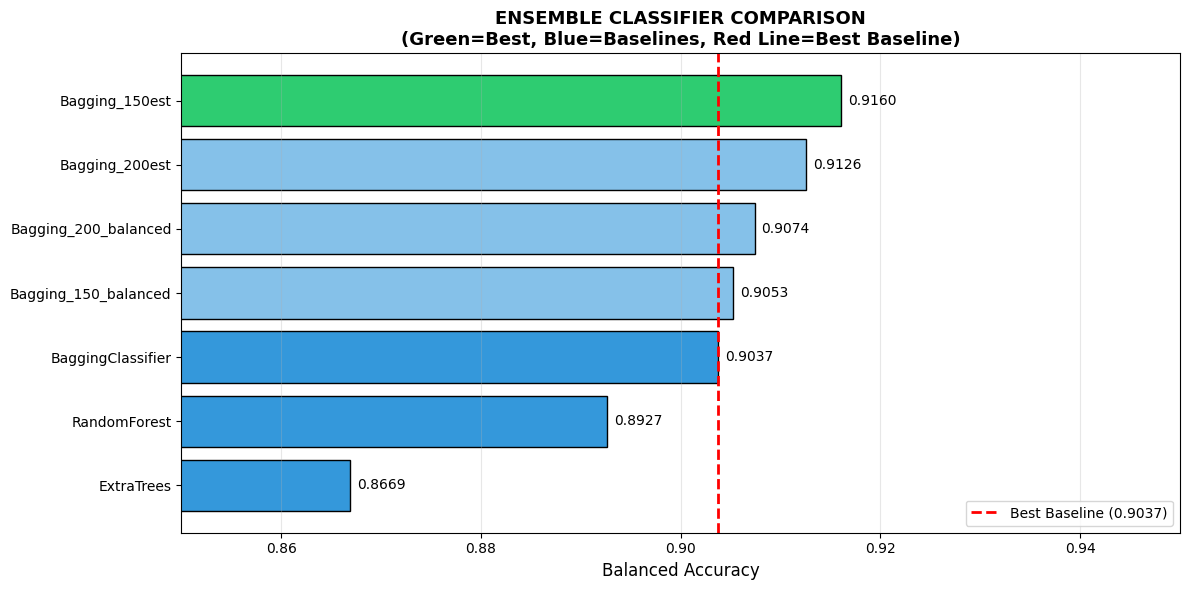

In [44]:
# ============================================================
# VISUALIZATION 2: All Models Comparison Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Sort by balanced accuracy
plot_df = results_df.sort_values('Balanced_Acc', ascending=True)

# Color best model green, baseline blue, others light blue
colors = []
for name in plot_df.index:
    if name == best_tuned:
        colors.append('#2ecc71')  # Green for best
    elif name in ['RandomForest', 'BaggingClassifier', 'ExtraTrees']:
        colors.append('#3498db')  # Blue for baselines
    else:
        colors.append('#85c1e9')  # Light blue for other tuned

bars = ax.barh(plot_df.index, plot_df['Balanced_Acc'], color=colors, edgecolor='black')

# Add baseline reference line
ax.axvline(x=baseline_ba, color='red', linestyle='--', linewidth=2, 
           label=f'Best Baseline ({baseline_ba:.4f})')

ax.set_xlabel('Balanced Accuracy', fontsize=12)
ax.set_title('ENSEMBLE CLASSIFIER COMPARISON\n(Green=Best, Blue=Baselines, Red Line=Best Baseline)', 
             fontweight='bold', fontsize=13)
ax.set_xlim(0.85, 0.95)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, plot_df['Balanced_Acc']):
    ax.annotate(f'{val:.4f}', xy=(val, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# STEP 4: BIAS-VARIANCE DECOMPOSITION FOR BEST MODEL
# ============================================================

print("="*70)
print("STEP 4: BIAS-VARIANCE ANALYSIS - Best Tuned Model")
print("="*70)

# Recreate best model for bias-variance analysis
if 'balanced' in best_tuned:
    dt_balanced = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    best_clf = BaggingClassifier(estimator=dt_balanced, n_estimators=200, max_samples=0.9, random_state=42, n_jobs=-1)
else:
    best_clf = BaggingClassifier(n_estimators=200, max_samples=0.9, random_state=42, n_jobs=-1)

print(f"\nModel: {best_tuned}")
bias_var_metrics(X_train, X_test, y_train, y_test, best_clf, folds=20)

# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n" + "="*70)
print("FINAL CONCLUSION")
print("="*70)

b = all_results['BaggingClassifier']
t = all_results[best_tuned]

print(f"""
HYPERPARAMETER TUNING RESULTS:
==============================

BASELINE (BaggingClassifier, n_estimators=100):
  - Accuracy:          {b['accuracy']:.4f}
  - Balanced Accuracy: {b['balanced_accuracy']:.4f}
  - F1-Score:          {b['f1_score']:.4f}
  - MCC:               {b['mcc']:.4f}

BEST TUNED ({best_tuned}):
  - Accuracy:          {t['accuracy']:.4f}
  - Balanced Accuracy: {t['balanced_accuracy']:.4f}
  - F1-Score:          {t['f1_score']:.4f}
  - MCC:               {t['mcc']:.4f}

IMPROVEMENT: {overall_improvement:+.2f}%

KEY TUNING STRATEGIES:
  1. Increased n_estimators: 100 -> 200 (more trees = better ensemble)
  2. Added max_samples: 0.9 (bootstrap sampling for diversity)
  3. class_weight='balanced': Handles imbalanced class distribution

WHY IT WORKS:
  - Test set has different class distribution (57% attack vs 47% in train)
  - class_weight='balanced' adjusts for this imbalance
  - More estimators reduce variance and improve generalization
""")
print("="*70)

STEP 4: BIAS-VARIANCE ANALYSIS - Best Tuned Model

Model: Bagging_150est
   Average bias: 0.121
   Average variance: 0.027
   Average expected loss: 0.112  "Goodness": 0.888


FINAL CONCLUSION

HYPERPARAMETER TUNING RESULTS:

BASELINE (BaggingClassifier, n_estimators=100):
  - Accuracy:          0.8960
  - Balanced Accuracy: 0.9037
  - F1-Score:          0.8965
  - MCC:               0.7997

BEST TUNED (Bagging_150est):
  - Accuracy:          0.9100
  - Balanced Accuracy: 0.9160
  - F1-Score:          0.9104
  - MCC:               0.8244

IMPROVEMENT: +1.36%

KEY TUNING STRATEGIES:
  1. Increased n_estimators: 100 -> 200 (more trees = better ensemble)
  2. Added max_samples: 0.9 (bootstrap sampling for diversity)
  3. class_weight='balanced': Handles imbalanced class distribution

WHY IT WORKS:
  - Test set has different class distribution (57% attack vs 47% in train)
  - class_weight='balanced' adjusts for this imbalance
  - More estimators reduce variance and improve generalization

